# FE621 HW4

Cian Gahan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from FE621.pricing.monte_carlo import GBMEuropean, GBMEuropeanCV, CEVEuropean, GBMAsian, GBMUOBarrier
from FE621.pricing.black_scholes import BlackScholes
from FE621.pricing.tree import TrinomialTree

## Question 1: Comparing Monte Carlo Schemes

Consider the Black-Scholes setup (geometric Brownian motion) with annual parameters $r = 4\%$, $\sigma = 60\%$, $S_0 = 100$, and assume we want to price a European option with strike $K = 100$ and maturity $T = 0.5$.

a) Implement a simple Monte Carlo scheme using m simulation trials for European Call and Put options. This should be a function of n (number of time steps) and m. In all practical applications you should use at least 300 time steps and at least 1 million simulated paths. Furthermore, implement a calculation of the standard error of the estimate of the option price and a way to time the simulation routine. Please output the results obtained when varying n (300 -700) and m (1-5 million). Study the time and precision as you increase n and m. Summarize your work with representative tables/graphs. Outputting too much or too little will lose points. What is the best combination in your opinion?

Note: n is irrelevant here as the option has no path dependence and the stock terminal value can be sufficiently simulated with a single normal random draw. Arguably this increases precision slightly as it is a single normal random variable scaled by time vs hundreds of normal random variables truncated at the system precision limit then summed up. Therefore to increase simulation efficiency I am just using m in my GBM european option simulation and will reintroduce n for control variate/other stoch processes below

In [2]:
r=0.04
sigma=0.6
s0=100
k=100
T=0.5

bs_call = BlackScholes.call(s0, k, T, r, sigma)
bs_put = BlackScholes.put(s0, k, T, r, sigma)
print("Black Scholes Call Price:", bs_call)
print("Black Scholes Put Price:", bs_put)
gbm = GBMEuropean(r, s0, k, T, sigma)

res = pd.DataFrame(columns=["M", "Call Value", "Call Stderr", "Call Time", "Put Value", "Put Stderr", "Put Time"])
for m in np.arange(1000000,5000001,500000):
    cv, cs, ct = gbm.simulate(m, av=False, call=True)
    pv, ps, pt = gbm.simulate(m, av=False, call=False)
    res.loc[m] = (m, cv, cs, ct, pv, ps, pt)
res.set_index("M", inplace=True)
res

Black Scholes Call Price: 17.64153804231836
Black Scholes Put Price: 15.661405372993883


,Call Value,Call Stderr,Call Time,Put Value,Put Stderr,Put Time
M,,,,,,
1000000.0,17.636434,0.032717,0.017216,15.642915,0.018699,0.016596
1500000.0,17.636486,0.026717,0.024664,15.642867,0.015269,0.022229
2000000.0,17.656306,0.023131,0.033085,15.660363,0.013233,0.032446
2500000.0,17.650050,0.020686,0.041491,15.663567,0.011834,0.041564
3000000.0,17.635334,0.018887,0.053066,15.648589,0.010799,0.050559
3500000.0,17.648686,0.017483,0.071373,15.652659,0.010000,0.057942
4000000.0,17.631815,0.016325,0.083068,15.674684,0.009359,0.064302
4500000.0,17.631554,0.015400,0.088337,15.652341,0.008820,0.072206
5000000.0,17.653407,0.014628,0.097527,15.661633,0.008371,0.083652


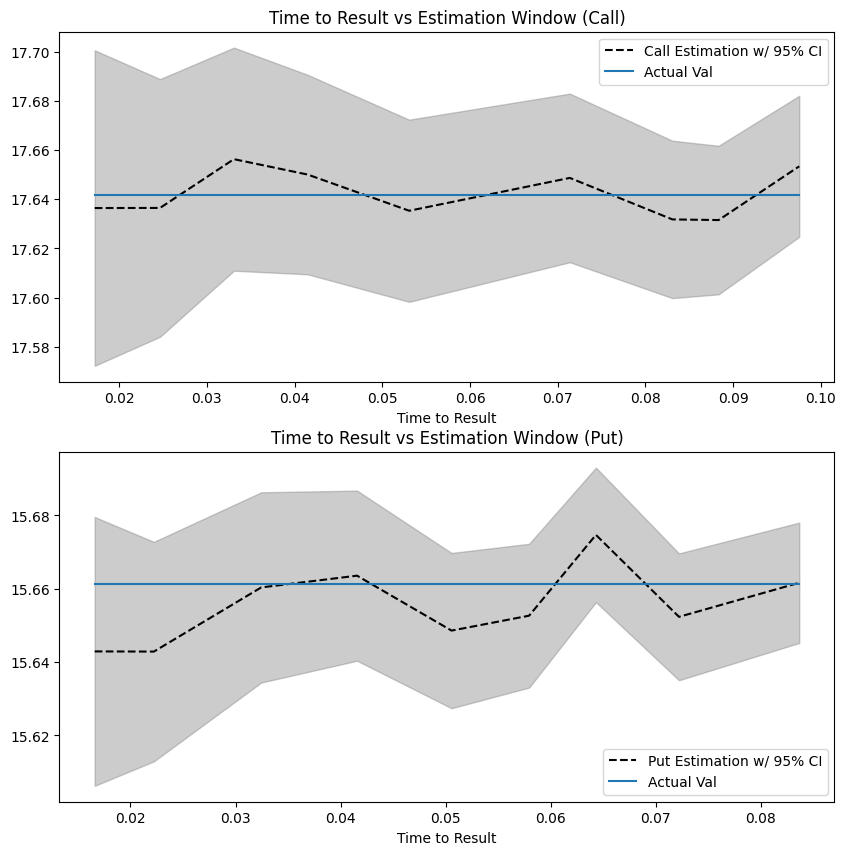

In [3]:
fig, axs = plt.subplots(2, 1, figsize=(10,10))
axs[0].plot(res["Call Time"], res["Call Value"], "k--", label="Call Estimation w/ 95% CI")
axs[0].fill_between(
    res["Call Time"], 
    res["Call Value"] + 1.96 * res["Call Stderr"], 
    res["Call Value"] - 1.96 * res["Call Stderr"], color="gray", alpha=0.4
)
axs[0].plot(res["Call Time"], [bs_call] * len(res), label="Actual Val")
axs[0].set_xlabel("Time to Result")
axs[0].legend()
axs[0].set_title("Time to Result vs Estimation Window (Call)")

axs[1].plot(res["Put Time"], res["Put Value"], "k--", label="Put Estimation w/ 95% CI")
axs[1].fill_between(
    res["Put Time"], 
    res["Put Value"] + 1.96 * res["Put Stderr"], 
    res["Put Value"] - 1.96 * res["Put Stderr"], color="gray", alpha=0.4
)
axs[1].plot(res["Put Time"], [bs_put] * len(res), label="Actual Val")
axs[1].set_xlabel("Time to Result")
axs[1].legend()
axs[1].set_title("Time to Result vs Estimation Window (Put)")
plt.show()

Looking over the table and charts, I would say that roughly 1.5-2.5 million simulations seems to be the sweet spot (towards the lower end of tested values). The averages don't seem to get significantly more accurate/closer to the Black Scholes solution as the number of simulations increase, and the standard error remains roughly the same as well due to it increasing with the square root of the simulation count. Since the execution time increases linearly with limited return, the most efficient solution seems to be to stick to the lower end. Plotting the execution time against the estimated option price range directly in the latter two charts shows the diminishing/almost nonexistent return of additional computation time more explicitly, supporting the idea that the lower end of simulation count will provide the most efficient approach.

b) Implement a Monte Carlo scheme for European call and put options using the antithetic variates method, the delta–based control variate with $\beta_1 = −1$, and the combined antithetic variates with delta-based control variate method. Report the values obtained in four columns: Monte Carlo (MC), MC with Antithetic Variates, MC with Delta-based Control Variate, and MC with both Antithetic Variates and Delta-based Control Variate. Report the estimated option values, the corresponding standard deviations, as well as the time it takes to obtain each result. Write a short paragraph comparing the results you obtained. Discuss the methods implemented.

In [4]:
test = GBMEuropeanCV(r, s0, k, T, sigma)
test.simulate(5, 5, False, False)

(np.float64(17.19729056834111),
 np.float64(2.300793960398926),
 0.0002512499922886491)

In [5]:
n = 500
m = 2500000
m_cv = 25000
# #columns=["MC", "MC w/ AV", "MC w/ CV", "MC w/ CV and AV"]
res2 = pd.DataFrame()

res2["MC"] = [m] + list(gbm.simulate(m, av=False, call=True)) + list(gbm.simulate(m, av=False, call=False))
res2["MC w/ AV"] = [m] + list(gbm.simulate(m, av=True, call=True)) + list(gbm.simulate(m, av=True, call=False))

gbm_cv = GBMEuropeanCV(r, s0, k, T, sigma)
res2["MC w/ CV"] = [m_cv] + list(gbm_cv.simulate(m_cv, n, av=False, call=True)) + \
    list(gbm_cv.simulate(m_cv, n, av=False, call=False))
res2["MC w/ CV and AV"] = [m_cv] + list(gbm_cv.simulate(m_cv, n, av=True, call=True)) + \
    list(gbm_cv.simulate(m_cv, n, av=True, call=False))

res2.index = ["M", "Call Value", "Call Stderr", "Call Time", "Put Value", "Put Stderr", "Put Time"]

print("Black Scholes Call Price:", bs_call)
print("Black Scholes Put Price:", bs_put)

with pd.option_context('display.float_format', lambda x: '%.5f' % x if x < 1000 else '%.0f' % x):
    print(res2)

Black Scholes Call Price: 17.64153804231836
Black Scholes Put Price: 15.661405372993883
                  MC  MC w/ AV  MC w/ CV  MC w/ CV and AV
M            2500000   2500000     25000            25000
Call Value  17.63322  17.66824  17.63789         17.64477
Call Stderr  0.02070   0.01466   0.00413          0.00288
Call Time    0.04293   0.05598   0.67333          1.36565
Put Value   15.67545  15.66398  15.65779         15.65944
Put Stderr   0.01184   0.00837   0.00408          0.00291
Put Time     0.04059   0.05760   0.54399          1.18026


While testing I found that with similar M values, the CV method took a lot longer and produced far more precise results than the simple MC method, so I adjusted the M values for the comparison in order to make the results easier to interpret.

With varied M values and N = 500, the winner seems to be between the standard Monte Carlo and the Monte Carlo w/ antithetic variates. Since I used a more efficient simulation method (see earlier) this makes sense; even with 2.5 million simulations vs 25000 in the CV methods, the 500 time steps mean the CV methods still generate on the order of 1 million random variables and have to perform significant additional calculations, so this is not unexpected.

To justify this selection, I looked at the standard error and time, where the CV method took 0.55 sec while the simple MC took 0.04-0.05 sec. However the stderr was around 3 times higher for the standard MC, compared to the 10x time difference, so it appears the simple MC may be more efficient. The MC with AV was more accurate, as its mean was closer to the true black-scholes value (within 1-2std), but this could have been due to chance. 

If greater precision is required than the 0.01 stderr result I think the MC with CV would be more appropriate regardless of the lower efficiency. Recalling the earlier graph of how the stderr tapered very slowly, achieving a comparable stderr might take a lot more simulations and time to reach, losing its apparent advantage over CV.

So overall I would say it is a rough tie between MC with AV and MC with CV, with the better one depending on the use case priority (precision vs speed). If given a chance to revisit I would want to refactor my CV code using some of the more efficient simulation logic I created for the below problems and test higher simulation numbers to see how the accuracy changes.

## Problem 2: Monte Carlo with Jumps

Assume the Stock process follows a Constant Elasticity of Variance (CEV) model with jumps.
Specifically, if we let Rt = log St denote the logarithm of the Stock process, then:

$$
dR_t = (r - \lambda \kappa - \frac{\sigma^2 S^{\beta - 2}_t}{2}) dt + \sigma S^{\frac{\beta - 2}{2}}_t dW_t + dY_t
$$

In this equation when discretizing it, ∆Yt = Yt − Yt−∆t is the increment of the
compound Poisson process which is the sum of jump values over the interval
[t − ∆t, t]. The parameters to be used are the following. Initial stock value
S0 = 100, R0 = log 100, and annual parameter values are: risk-free rate r =
0.01, expected number of jumps λ = 104 (biweekly), the size of the jumps in Yt
are i.i.d. random variables distributed as Normal random variables with mean
μJ = −0.01 and variance σ2
J = 0.1. And $\kappa = E[eJ − 1] = e^{\mu_J +\sigma^2_j / 2} - 1$
 is the
Merton jump compensator ensuring the discounted stock price is a martingale
under the risk-neutral measure Q. Parameters σ = 0.3 and β = 1.2.

1-2) Please use Monte Carlo simulations to price a European Put Option with
maturity 1 month and strike price 100. Use 300 steps and 1 million simulation. Estimate a 95% confidence interval
for the value of the European Put Option.

In [6]:
r = 0.01
s0 = 100
k = 100
T = 1/12
sigma = 0.3
beta = 1.2
l = 104 # lambda
mu_j = -0.01
sigma_j = np.sqrt(0.1)

# see src/FE621/pricing/monte_carlo.py for implementation
cev = CEVEuropean(
    r,
    s0,
    k,
    T,
    sigma,
    beta,
    l,
    mu_j,
    sigma_j
)
put_val, put_stderr = cev.simulate(1000000, 300, False)

print("Estimated Option Value:", put_val)
print("95% Confidence Interval:", put_val - 1.96 * put_stderr, put_val + 1.96 * put_stderr)

Estimated Option Value: 35.855840460184716
95% Confidence Interval: 35.79361339203003 35.9180675283394


3) Can you use the Put-Call Parity to calculate the price of a European Call
option with the same maturity and strike price. If you can please provide
the answer. If you cannot please explain why you cannot calculate it.

Yes, put call parity will always apply for european options even with jumps. Demonstrating below, the parity estimate matches the call valuation from the same simulation:

In [7]:
print("Parity Estimate:", put_val - s0 + k * np.exp(r * T))

call_val, call_stderr = cev.simulate(1000000, 300, True)
print("Estimated Call Value:", call_val)
print("95% Confidence Interval:", call_val - 1.96 * call_stderr, call_val + 1.96 * call_stderr)

Parity Estimate: 35.93920852538734
Estimated Call Value: 35.90596293436598
95% Confidence Interval: 35.67462404852893 36.13730182020303


4) Now let us look at the impact of the jumps. Price the same European put
as in point 1. but set the time interval of jump to $\infty$. Figure out a way to
reuse your code.

Setting the time between jumps to infinity is effectively the same as having no jumps. so it is simple to rerun the simulation with this change:

In [8]:
cev.l = 0

put_val_nj, put_stderr_nj = cev.simulate(1000000, 300, False)
print("Estimated Put Value without jumps:", put_val_nj)
print("95% Confidence Interval:", put_val_nj - 1.96 * put_stderr_nj, put_val_nj + 1.96 * put_stderr_nj)

Estimated Put Value without jumps: 0.5066251492025299
95% Confidence Interval: 0.5051199731679612 0.5081303252370986


It seems that the jumps add a significant amount of value to the option. This makes sense as the jumps have relatively high frequency and a large variance/volatility relative to that of the underlying process

# Problem 3: Path-Dependent options using Monte Carlo

In this question, we shall consider the valuation of two representative path-
dependent options using the Monte Carlo method. The stock price pays a
continuous dividend rate and is assumed to follow a geometric Brownian motion
with yearly parameters: S0 = 100, K = 100, r = 3%, $\delta = 1\%$, σ = 20%, T = 1.
The number of time steps is n = 120, and the number of simulations is m = 1
million.

a) Consider the valuation of a discretely-monitored arithmetic Asian call option. Assume there are 12 monitoring points, i.e. the stock price is monitored every month, $t_i = i/12, i = 1, . . . , 12,$ and the payoff is given by

$$
(\frac{1}{12}\sum_{i=1}^{12}{S_{t_i} - K})^+
$$

Given the underlying process is geometric brownian motion, only 12 time steps are required to simulate the process effectively since the monitoring frequency is once a month. Increasing beyond that will not change the result as the sum of intermediate increments are still normal and can be simulated directly with a single random draw.

In [9]:
r = 0.03
d = 0.01
s0 = 100
k = 100
sigma = 0.2
T = 1

# see src/FE621/pricing/monte_carlo.py for implementation
gbm_asian = GBMAsian(
    r,
    d,
    s0,
    k,
    T,
    sigma
)

asian_call_val, asian_call_stderr = gbm_asian.simulate(1000000, 12, True)
print("Estimated Asian Option Value:", asian_call_val)
print("95% Confidence Interval:", asian_call_val - 1.96 * asian_call_stderr, asian_call_val + 1.96 * asian_call_stderr)

Estimated Asian Option Value: 5.32346897595123
95% Confidence Interval: 5.307774369120489 5.339163582781971


b) Consider the valuation of a discretely-monitored up and out barrier call
option. The barrier level is H = 110. Assume there are 12 monitoring
points, i.e. the stock price is monitored every month, $t_i = i/12 , i = 1, . . . , 12,$
and the payoff is given by 

$$
(S_T - K)^+ \mathbb{1}_{\{\max_{0 < i \le 12} S_{t_i} \le H\}}
$$

In [10]:
r = 0.03
d = 0.01
s0 = 100
k = 100
h = 110
sigma = 0.2
T = 1

# see src/FE621/pricing/monte_carlo.py for implementation
gbm_uocall = GBMUOBarrier(
    r,
    d,
    s0,
    k,
    h,
    T,
    sigma
)

uo_call_val, uo_call_stderr = gbm_uocall.simulate(1000000, 12, True)
print("Estimated Up and Out Call Option Value:", uo_call_val)
print("95% Confidence Interval:", uo_call_val - 1.96 * uo_call_stderr, uo_call_val + 1.96 * uo_call_stderr)

tree = TrinomialTree(r, sigma, s0, T, 1000)
print("Trinomial Tree Up and Out Call Price:", tree.price_barrier_option_knock_out(k, h, True))

Estimated Up and Out Call Option Value: 0.3050609948796241
95% Confidence Interval: 0.3025178377410604 0.30760415201818786
Trinomial Tree Up and Out Call Price: 0.1337639871308358


We can see that the Up and out barrier call option is overvalued in the Monte Carlo simulation compared to the trinomial tree model, even with 1 million simulations. This is likely due to the lower monitoring frequency (the Monte Carlo price is monitored monthly while the trinomial tree price is monitored at every time step) which causes the Monte Carlo option to have an artifically low probability of being knocked out. Adding additional time steps will not change this as long as the monitoring frequency remains low.

By increasing the monitoring frequency (1200 times a year), I can verify that the price convergest to that of the trinomial tree:

In [11]:
uo_call_val_hf, uo_call_stderr_hf = gbm_uocall.simulate(1000000, 1200, True)
print("Estimated Up and Out Call Option Value (High Monitoring Freq):", uo_call_val_hf)
print("95% Confidence Interval:", uo_call_val_hf - 1.96 * uo_call_stderr_hf, uo_call_val_hf + 1.96 * uo_call_stderr_hf)

Estimated Up and Out Call Option Value (High Monitoring Freq): 0.13396567583041505
95% Confidence Interval: 0.13238284338201955 0.13554850827881054
